##### Extract GWL daily timeseries data as csv file from the .uhd binary data

In [1]:
import flopy.utils.binaryfile as bf
import pandas as pd
import numpy as np

def extract_surface_head_timeseries(bdh_file, col, row):
    """
    Extracts the head values from the first non-dry (saturated) layer for a given column and row.
    
    Parameters:
        bdh_file (str): Path to the MODFLOW binary head file.
        col (int): Column index.
        row (int): Row index.

    Returns:
        pd.DataFrame: DataFrame containing Time and Surface Head values.
    """
    # Load binary head file
    head_obj = bf.HeadFile(bdh_file)
    
    # Get simulation times
    times = head_obj.get_times()
    
    # Extract surface heads
    surface_heads = []
    
    for t in times:
        heads = head_obj.get_data(totim=t)  # 3D array of heads at this time step
        
        # Find the first non-dry (saturated) layer
        surface_head = np.nan  # Default to NaN if all layers are dry
        for layer in range(heads.shape[0]):
            if heads[layer, row, col] > -9999:  # Assuming -9999 is the MODFLOW dry cell value
                surface_head = heads[layer, row, col]
                break  # Stop at the first valid layer
        
        surface_heads.append(surface_head)
    
    # Create DataFrame
    df = pd.DataFrame({'Time': times, 'Surface_Head': surface_heads})
    
    return df

# Example Usage
bdh_file = "C:/Users/mgebremedhin/Documents/FGCU/BISECT/Model_new/farfuture/output/Output.future/timeBB.uhd"#timeBB.uhd"

# Specify row and column
col, row = 204,118  # Example coordinates

# Extract surface head data
surface_head_df = extract_surface_head_timeseries(bdh_file, col, row)

# Display the first few rows
print(surface_head_df.head())

# Save to CSV (optional)
surface_head_df.to_csv(f"C:/Users/mgebremedhin/Documents/FGCU/BISECT/PostProcessing/BISECT_Validation/GWL_head_timeseries_farfuture_SD_D_6hr_Head_grid_{col}_{row}.csv", index=False)


   Time  Surface_Head
0   1.0      0.035644
1   2.0      0.214596
2   3.0      0.253408
3   4.0      0.288653
4   5.0      0.314386


##### GW heads of each layer of the basline and future - last stress periods of each scenario (testing stage of BISECT model)

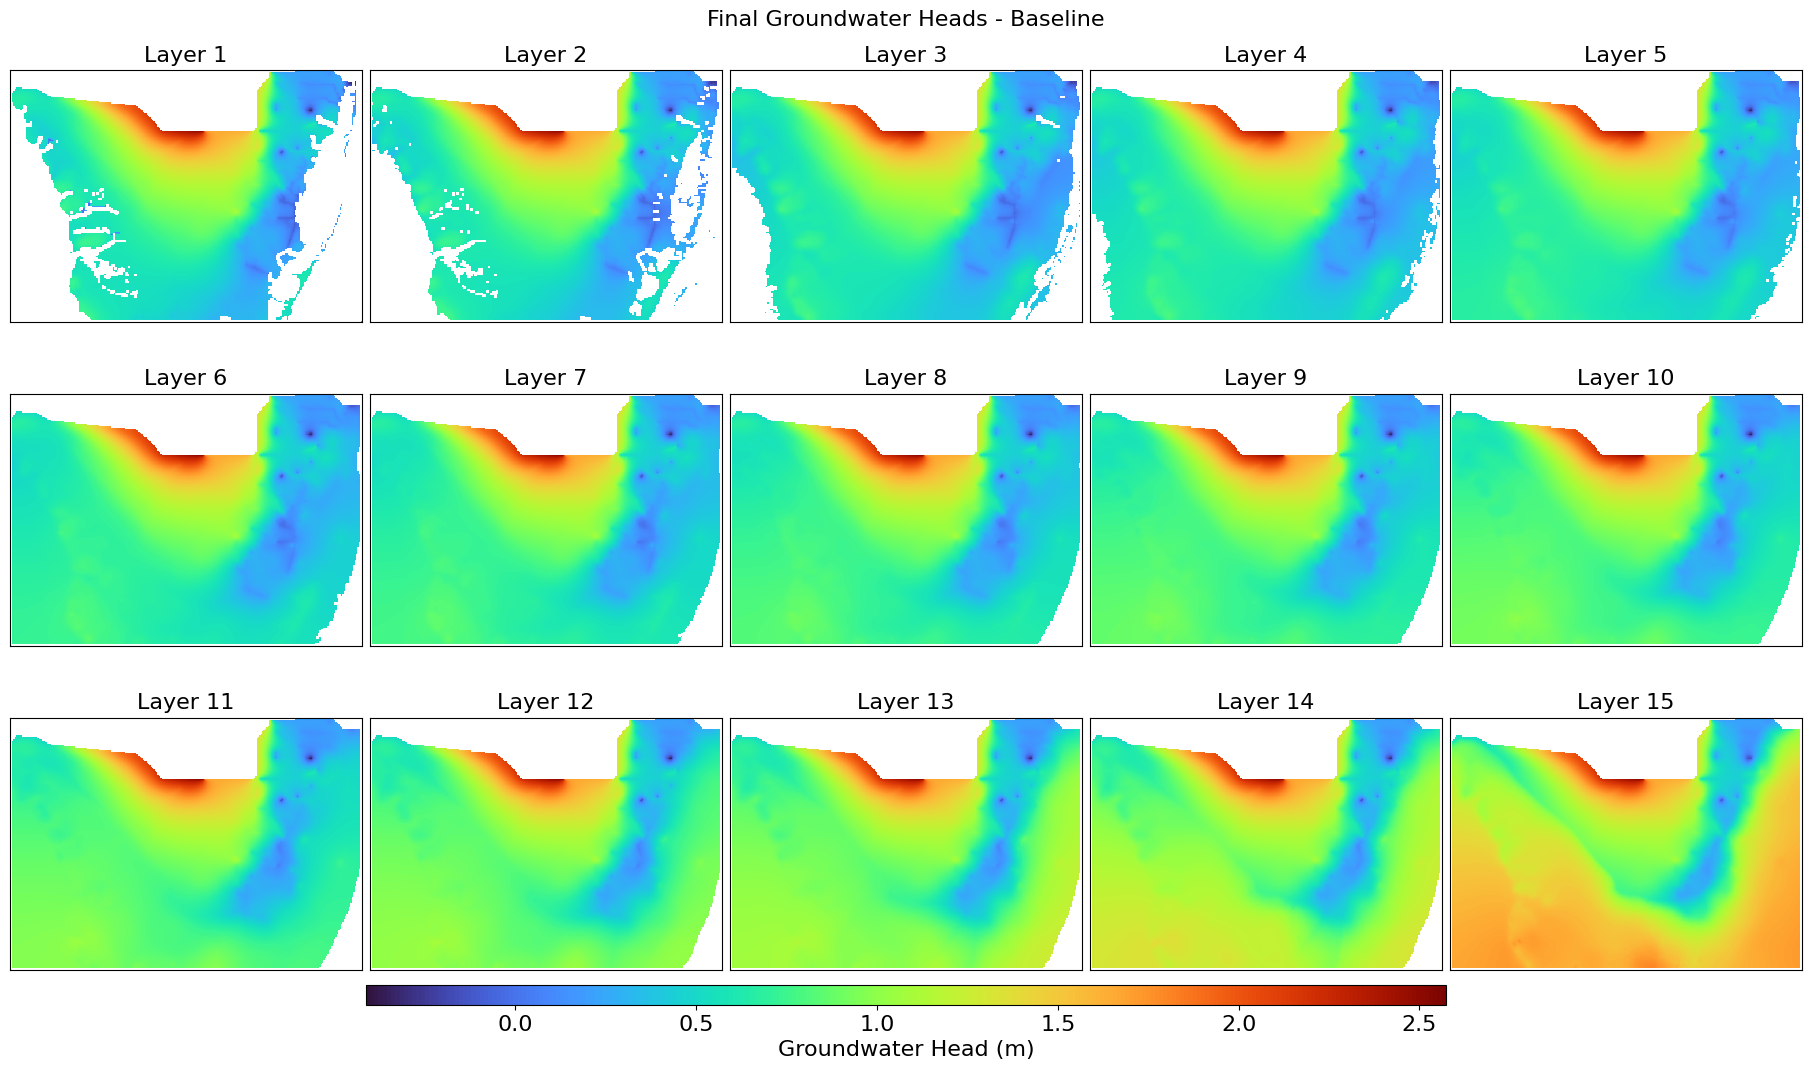

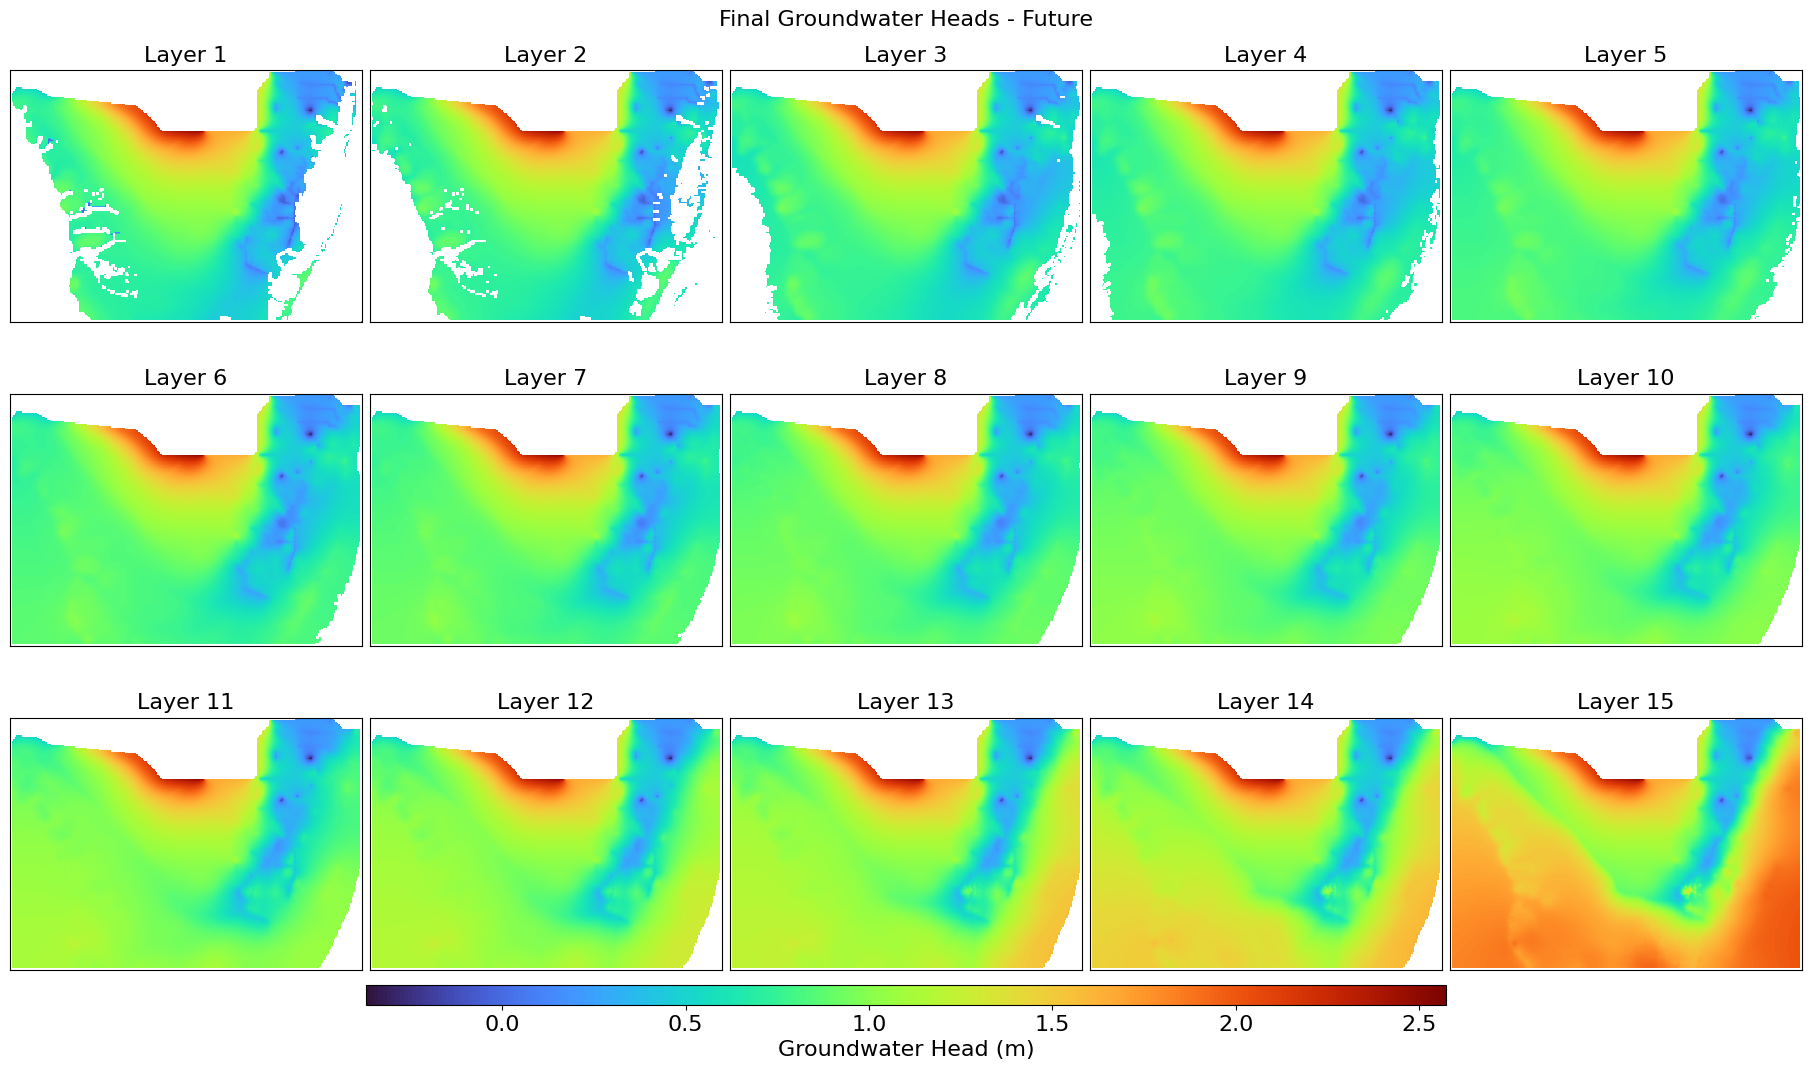

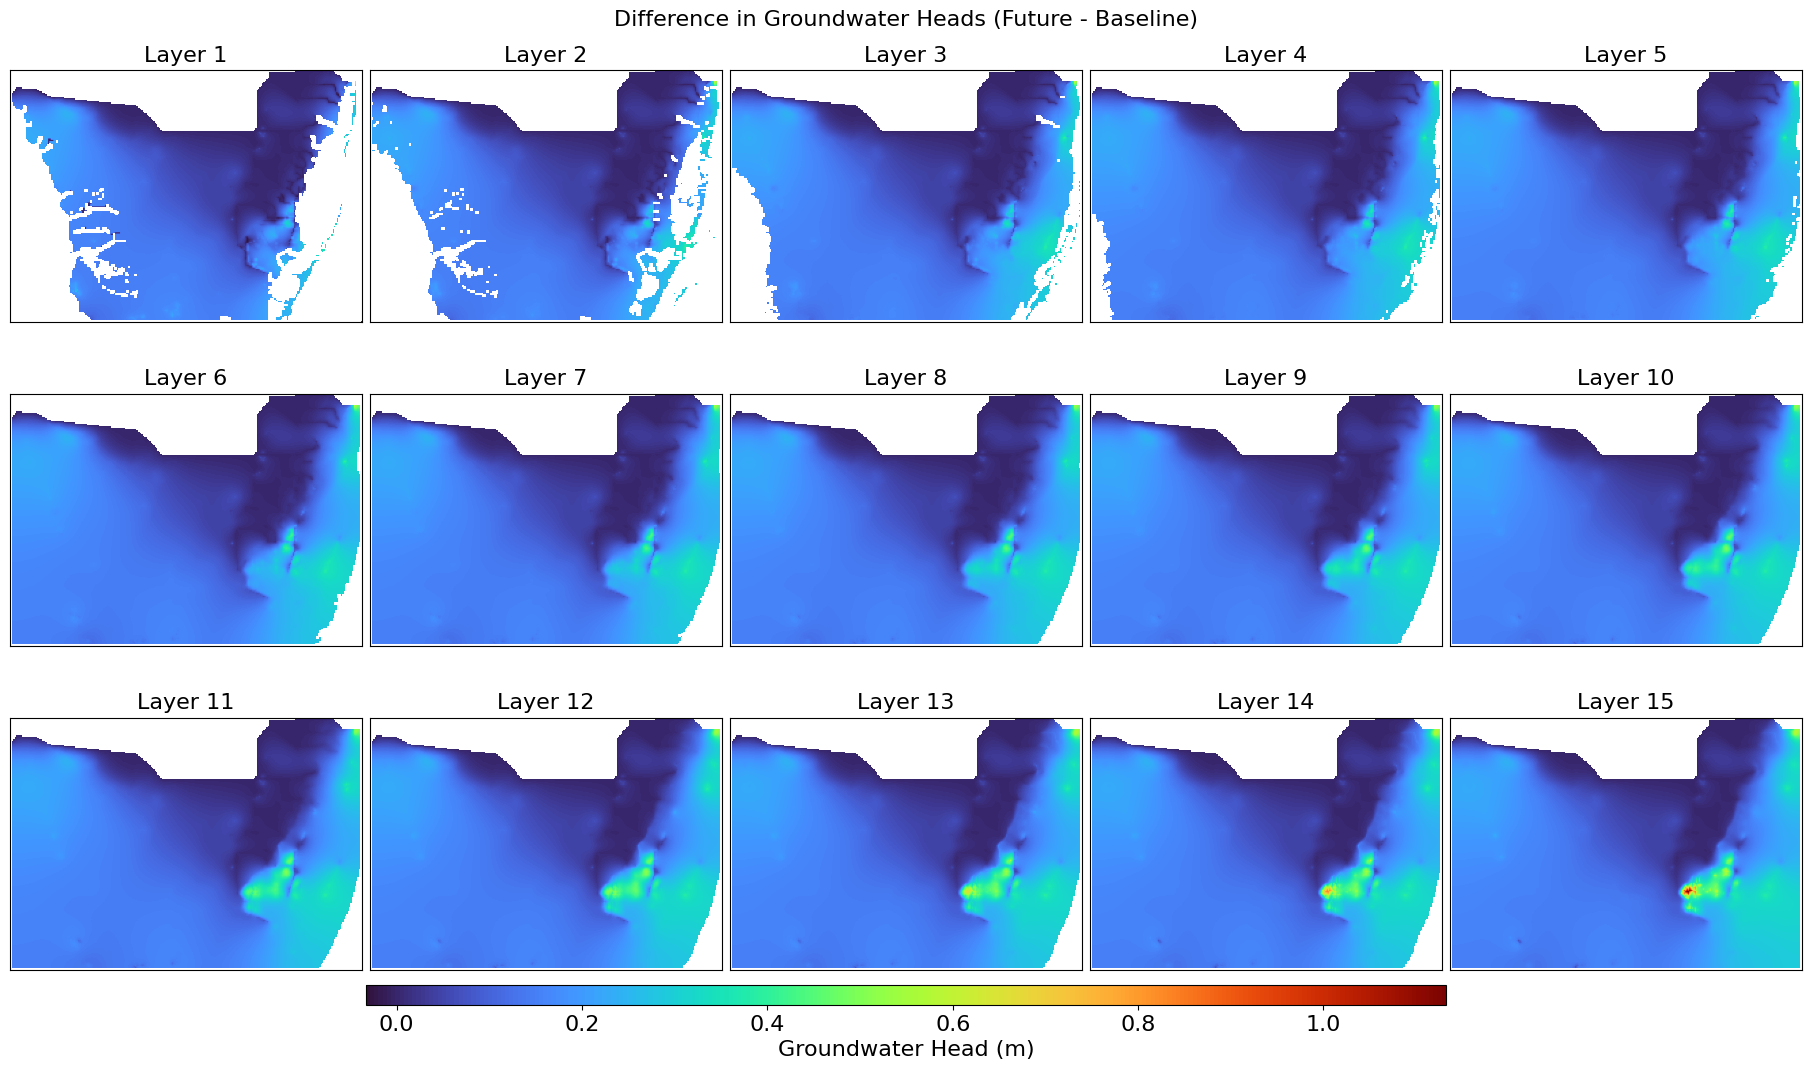

In [2]:
import flopy.utils.binaryfile as bf
import numpy as np
import rasterio
from rasterio.transform import from_origin
import matplotlib.pyplot as plt
import os
import matplotlib.colors as mcolors

def extract_heads_final(udh_file, final_stress_period=3286):
    """
    Extracts the spatial grid of head values for the final stress period,
    while treating -9999 values as inactive cells.
    """
    head_obj = bf.HeadFile(udh_file)
    heads_3d = head_obj.get_data(totim=final_stress_period)
    
    # Convert unwanted values (-9999) to NaN
    heads_3d = np.where(heads_3d == 999, np.nan, heads_3d)
    
    return heads_3d

def save_heads_layers_as_tiff(heads_3d, output_folder, prefix, left, right, top, bottom):
    """
    Saves each groundwater head layer as a separate GeoTIFF file.
    """
    os.makedirs(output_folder, exist_ok=True)
    nrows, ncols = heads_3d.shape[1], heads_3d.shape[2]
    
    cell_width = (right - left) / ncols
    cell_height = (top - bottom) / nrows
    transform = from_origin(left, top, cell_width, cell_height)

    for i in range(heads_3d.shape[0]):
        output_path = os.path.join(output_folder, f"{prefix}_Layer_{i+1}.tif")
        meta = {
            'driver': 'GTiff',
            'dtype': 'float32',
            'nodata': np.nan,
            'width': ncols,
            'height': nrows,
            'count': 1,
            'crs': 'EPSG:26917',
            'transform': transform
        }
        with rasterio.open(output_path, 'w', **meta) as dst:
            dst.write(heads_3d[i, :, :].astype(np.float32), 1)
        #print(f"Saved: {output_path}")

def plot_heads_layers(heads_3d, title, output_file, left, right, top, bottom):
    """
    Displays all groundwater head layers with a percent clip stretch type.
    """
    fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(18, 10), constrained_layout=True)
    
    extent = [left, right, bottom, top]
    vmin, vmax = np.nanpercentile(heads_3d, [0, 100])  # Percent clip stretch (0.5%-99.9%)
    cmap = plt.get_cmap("turbo")
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    for i, ax in enumerate(axes.flat):
        if i < heads_3d.shape[0]:
            img = ax.imshow(heads_3d[i, :, :], extent=extent, cmap=cmap, origin='upper', norm=norm)
            ax.set_title(f'Layer {i+1}', fontsize=16)
            ax.set_xticks([])
            ax.set_yticks([])

    cbar_ax = fig.add_axes([0.2, 0.001, 0.6, 0.02])
    cbar = fig.colorbar(img, cax=cbar_ax, orientation='horizontal')
    cbar.set_label('Groundwater Head (m)', fontsize=16)
    cbar.ax.tick_params(labelsize=16)

    plt.suptitle(title, fontsize=16)
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()

# File paths
baseline_udh = "C:/Users/mgebremedhin/Documents/FGCU/BISECT/Model_new/Baseline/output/Output.Baseline/timeBB.uhd"
future_udh = "C:/Users/mgebremedhin/Documents/FGCU/BISECT/Model_new/nearFuture/output/Output.Future/timeBB.uhd"
output_folder = "C:/Users/mgebremedhin/Documents/FGCU/BISECT/PostProcessing/GW_Heads/Tiff_Final"

# Define bounding box
left, right, top, bottom = 461000.0, 590500.0, 2872000.0, 2779000.0

# Extract heads for final stress period
heads_baseline_final = extract_heads_final(baseline_udh)
heads_future_final = extract_heads_final(future_udh)

# Compute difference (Future - Baseline)
heads_difference = heads_future_final - heads_baseline_final

# Save each layer as a TIFF file
save_heads_layers_as_tiff(heads_baseline_final, output_folder, "Heads_Baseline_Final", left, right, top, bottom)
save_heads_layers_as_tiff(heads_future_final, output_folder, "Heads_Future_Final", left, right, top, bottom)
save_heads_layers_as_tiff(heads_difference, output_folder, "Heads_Difference_Final", left, right, top, bottom)

# Display all layers
plot_heads_layers(heads_baseline_final, "Final Groundwater Heads - Baseline", 
                   "Heads_Baseline_Final.png", 
                   left, right, top, bottom)

plot_heads_layers(heads_future_final, "Final Groundwater Heads - Future", 
                   "Heads_Future_Final.png", 
                   left, right, top, bottom)

plot_heads_layers(heads_difference, "Difference in Groundwater Heads (Future - Baseline)", 
                   "Heads_Difference_Final.png", 
                   left, right, top, bottom)


### Time series Gw Salinity extraction 

In [6]:
import flopy.utils.binaryfile as bf
import pandas as pd
import numpy as np

def extract_salinity_timeseries(ucn_file, col, row):
    """
    Extracts the salinity (concentration) values for all layers at a given column and row.

    Parameters:
        ucn_file (str): Path to the MT3D UCN binary file.
        col (int): Column index.
        row (int): Row index.

    Returns:
        pd.DataFrame: DataFrame containing Time and Salinity values for each layer.
    """
    # Load the UCN file
    ucn_obj = bf.UcnFile(ucn_file)
    
    # Get simulation times
    times = ucn_obj.get_times()
    
    # Initialize list to store salinity values
    salinity_data = []

    for t in times:
        conc = ucn_obj.get_data(totim=t)  # 3D array of concentrations at this time step
        
        # Extract values from each layer at the given row, col
        layer_values = [conc[layer, row, col] for layer in range(conc.shape[0])]
        
        # Append time and salinity values
        salinity_data.append([t] + layer_values)

    # Create column names dynamically for all layers
    layer_columns = [f"Layer_{i+1}" for i in range(conc.shape[0])]
    
    # Create DataFrame
    df = pd.DataFrame(salinity_data, columns=["Time"] + layer_columns)
    
    return df

# Example Usage
ucn_file = "C:/Users/mgebremedhin/Documents/FGCU/BISECT/Model_new/Baseline/output/Output.Baseline/MT3D001.UCN"

# Specify row and column
col, row = 184, 144  # Example grid coordinates

# Extract salinity data for all layers
salinity_df = extract_salinity_timeseries(ucn_file, col, row)

# Display the first few rows
print(salinity_df.head())

# Save to CSV (optional)
output_file = f"C:/Users/mgebremedhin/Documents/FGCU/BISECT/PostProcessing/BISECT_Validation/Salinity_timeseries_Baseline_grid_{col}_{row}.csv"
salinity_df.to_csv(output_file, index=False)
#print(f"Saved CSV successfully: {output_file}")


   Time   Layer_1   Layer_2   Layer_3   Layer_4   Layer_5   Layer_6   Layer_7  \
0   1.0  0.679733  0.772024  1.338979  2.337256  3.610289  5.077246  6.852144   
1   2.0  0.679552  0.771788  1.339062  2.337384  3.610240  5.077137  6.851869   
2   3.0  0.679279  0.773035  1.341798  2.340626  3.613560  5.080600  6.855250   
3   4.0  0.679847  0.776326  1.348086  2.348184  3.621765  5.089721  6.864512   
4   5.0  0.680758  0.779984  1.354956  2.357055  3.631710  5.100378  6.874903   

    Layer_8    Layer_9   Layer_10   Layer_11   Layer_12   Layer_13   Layer_14  \
0  8.962332  11.327460  13.878865  16.679836  20.196846  21.343370  21.453350   
1  8.961963  11.327412  13.878721  16.679436  20.196201  21.343332  21.453348   
2  8.965066  11.329945  13.880394  16.680258  20.196302  21.343332  21.453354   
3  8.973144  11.336127  13.884745  16.682961  20.196623  21.343348  21.453398   
4  8.982054  11.342890  13.889488  16.685915  20.197044  21.343367  21.453440   

    Layer_15  
0  22.40038

###### Salinity for each layer of the baseline and farfuture and thier difference (average of all stress periods)

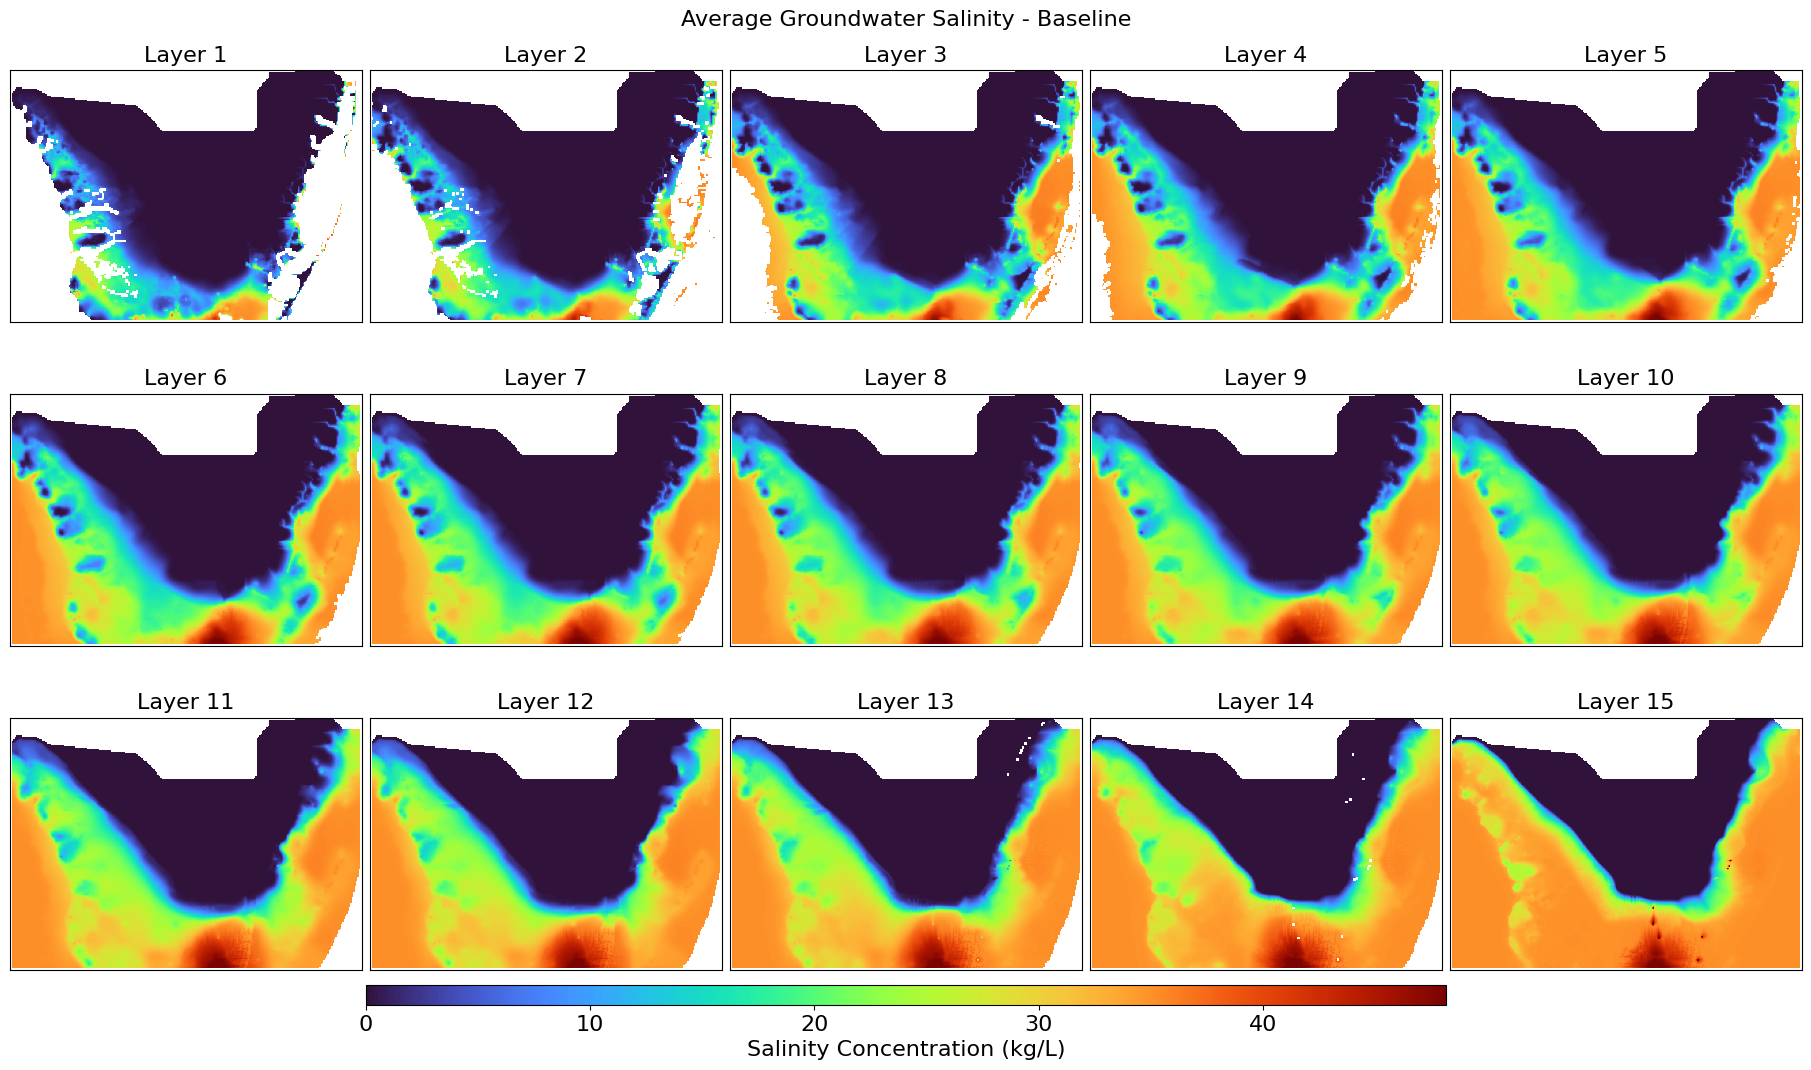

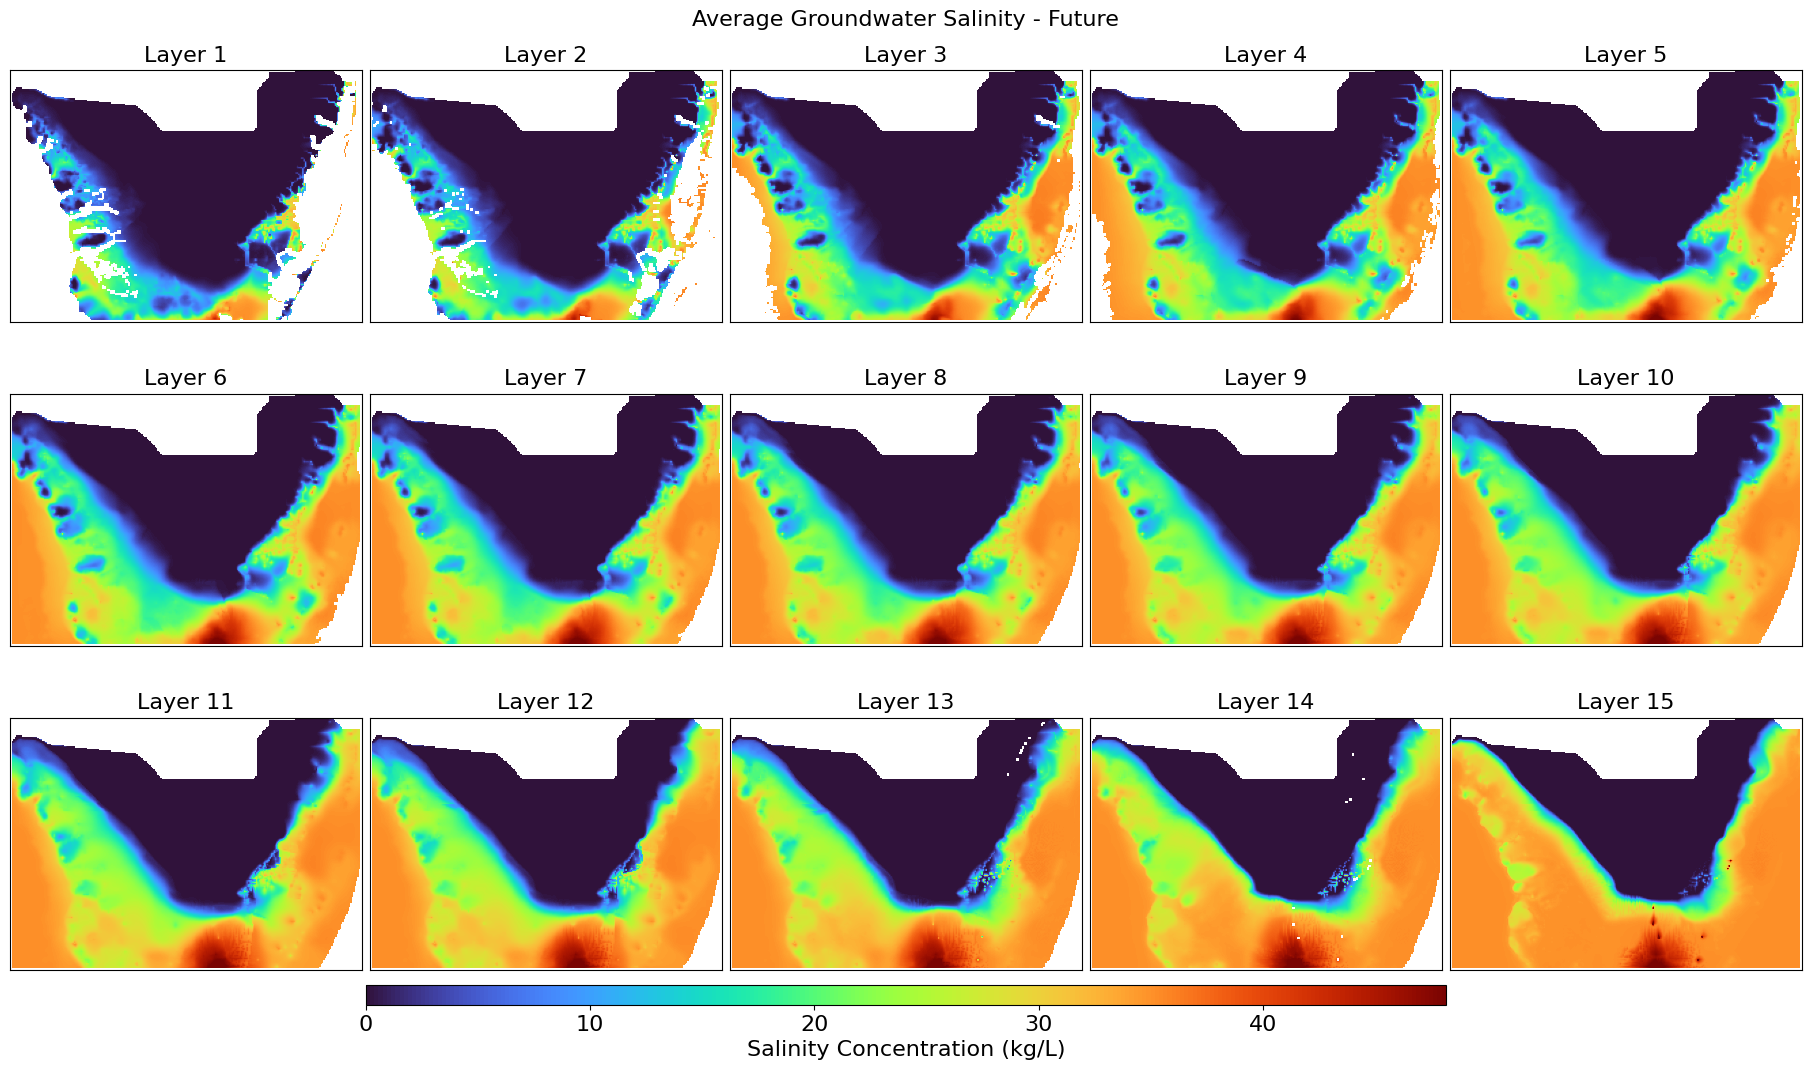

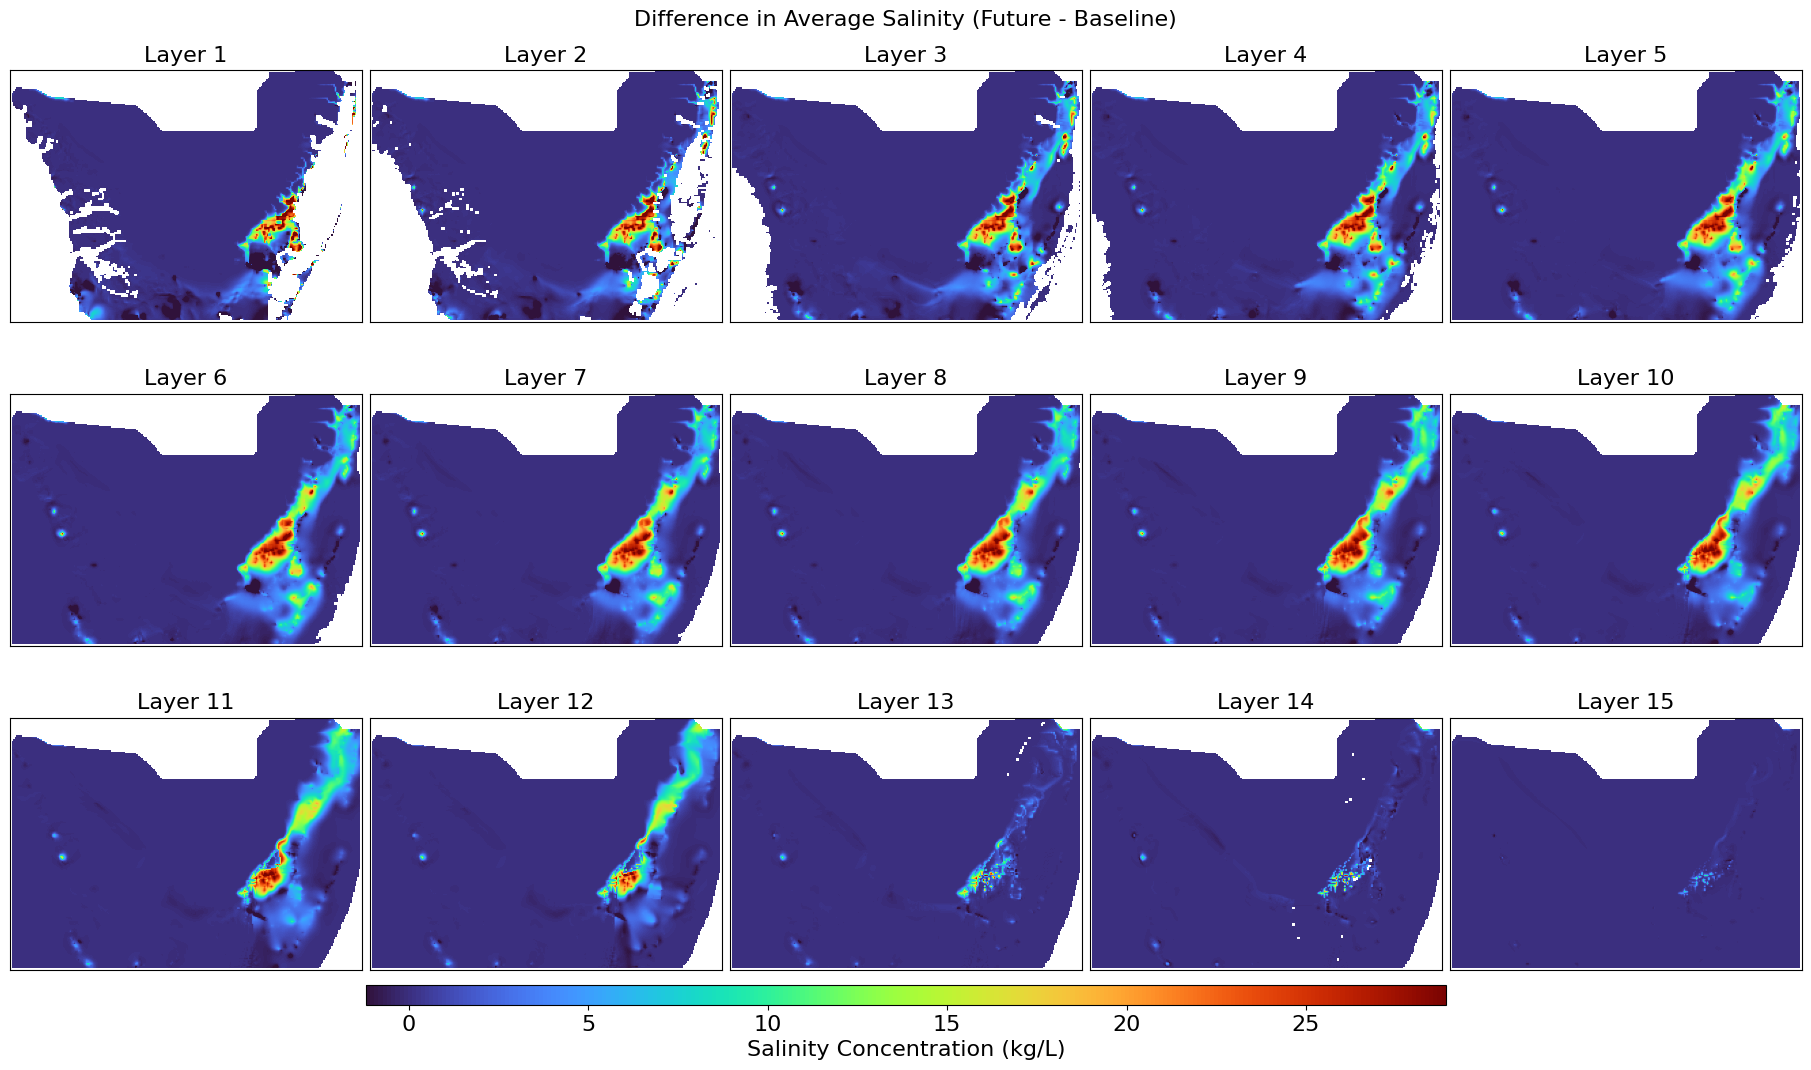

In [1]:
import flopy.utils.binaryfile as bf
import numpy as np
import rasterio
from rasterio.transform import from_origin
import matplotlib.pyplot as plt
import os
import matplotlib.colors as mcolors

def extract_salinity_avg(ucn_file):
    """
    Extracts and computes the average salinity across all stress periods.
    """
    ucn_obj = bf.UcnFile(ucn_file)
    times = ucn_obj.get_times()
    salinity_list = [ucn_obj.get_data(totim=t) for t in times]
    
    salinity_3d_avg = np.nanmean(np.where(np.isin(salinity_list, [-9999, 999, -1]), np.nan, salinity_list), axis=0)
    
    return salinity_3d_avg

def save_salinity_layers_as_tiff(salinity_3d, output_folder, prefix, left, right, top, bottom):
    """
    Saves each groundwater salinity layer as a separate GeoTIFF file.
    """
    os.makedirs(output_folder, exist_ok=True)
    nrows, ncols = salinity_3d.shape[1], salinity_3d.shape[2]
    
    cell_width = (right - left) / ncols
    cell_height = (top - bottom) / nrows
    transform = from_origin(left, top, cell_width, cell_height)

    for i in range(salinity_3d.shape[0]):
        output_path = os.path.join(output_folder, f"{prefix}_Layer_{i+1}.tif")
        meta = {
            'driver': 'GTiff',
            'dtype': 'float32',
            'nodata': np.nan,
            'width': ncols,
            'height': nrows,
            'count': 1,
            'crs': 'EPSG:26917',
            'transform': transform
        }
        with rasterio.open(output_path, 'w', **meta) as dst:
            dst.write(salinity_3d[i, :, :].astype(np.float32), 1)

def plot_salinity_layers(salinity_3d, title, output_file, left, right, top, bottom):
    """
    Displays all groundwater salinity layers with a percent clip stretch type.
    """
    fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(18, 10), constrained_layout=True)
    
    extent = [left, right, bottom, top]
    vmin, vmax = np.nanpercentile(salinity_3d, [0.5, 99.9])
    cmap = plt.get_cmap("turbo")
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    for i, ax in enumerate(axes.flat):
        if i < salinity_3d.shape[0]:
            img = ax.imshow(salinity_3d[i, :, :], extent=extent, cmap=cmap, origin='upper', norm=norm)
            ax.set_title(f'Layer {i+1}', fontsize=16)
            ax.set_xticks([])
            ax.set_yticks([])

    cbar_ax = fig.add_axes([0.2, 0.001, 0.6, 0.02])
    cbar = fig.colorbar(img, cax=cbar_ax, orientation='horizontal')
    cbar.set_label('Salinity Concentration (kg/L)', fontsize=16)
    cbar.ax.tick_params(labelsize=16)

    plt.suptitle(title, fontsize=16)
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()

# File paths
baseline_ucn = "C:/Users/mgebremedhin/Documents/FGCU/BISECT/Model_new/Baseline/output/Output.Baseline/MT3D001.UCN"
future_ucn = "C:/Users/mgebremedhin/Documents/FGCU/BISECT/Model_new/FarFuture/output/Output.Future/MT3D001.UCN"
output_folder = "C:/Users/mgebremedhin/Documents/FGCU/BISECT/PostProcessing/GW_Salinity/Tiff_Final"

# Define bounding box
left, right, top, bottom = 461000.0, 590500.0, 2872000.0, 2779000.0

# Extract average salinity over all stress periods
salinity_baseline_avg = extract_salinity_avg(baseline_ucn)
salinity_future_avg = extract_salinity_avg(future_ucn)

# Compute difference (Future - Baseline)
salinity_difference = salinity_future_avg - salinity_baseline_avg

# Save each layer as a TIFF file
save_salinity_layers_as_tiff(salinity_baseline_avg, output_folder, "Salinity_Baseline_Avg", left, right, top, bottom)
save_salinity_layers_as_tiff(salinity_future_avg, output_folder, "Salinity_Future_Avg", left, right, top, bottom)
save_salinity_layers_as_tiff(salinity_difference, output_folder, "Salinity_Difference_Avg", left, right, top, bottom)

# Display all layers
plot_salinity_layers(salinity_baseline_avg, "Average Groundwater Salinity - Baseline", 
                     "Salinity_Baseline_Avg.png", 
                     left, right, top, bottom)

plot_salinity_layers(salinity_future_avg, "Average Groundwater Salinity - Future", 
                     "Salinity_FarFuture_Avg.png", 
                     left, right, top, bottom)

plot_salinity_layers(salinity_difference, "Difference in Average Salinity (Future - Baseline)", 
                     "Salinity_Difference_Avg.png", 
                     left, right, top, bottom)
